#Problem 1 - A solution scheme based on neural network techniques 
  for a regression problem

Find Null columns
longitude             0.00
latitude              0.00
housing_median_age    0.00
total_rooms           0.00
total_bedrooms        1.03
population            0.00
households            0.00
median_income         0.00
median_house_value    0.00
ocean_proximity       0.00
dtype: float64


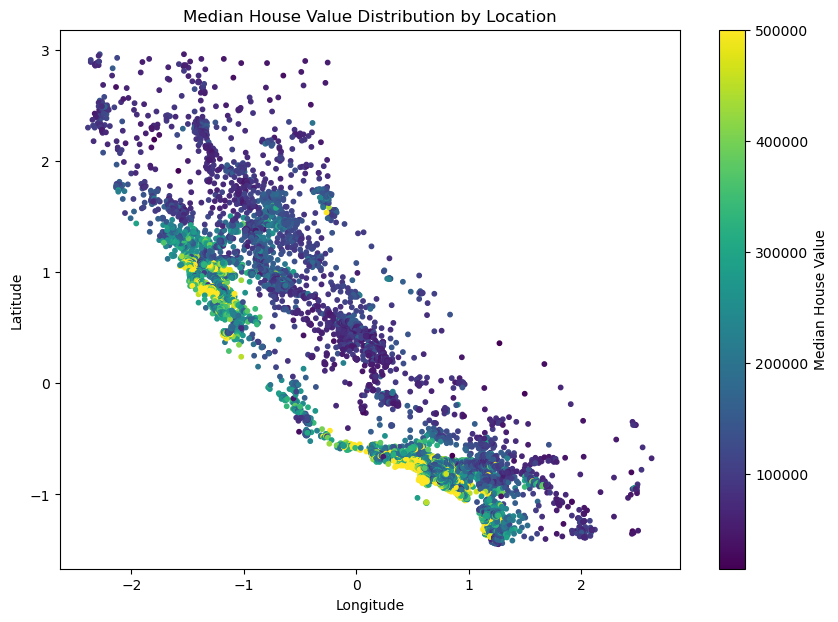

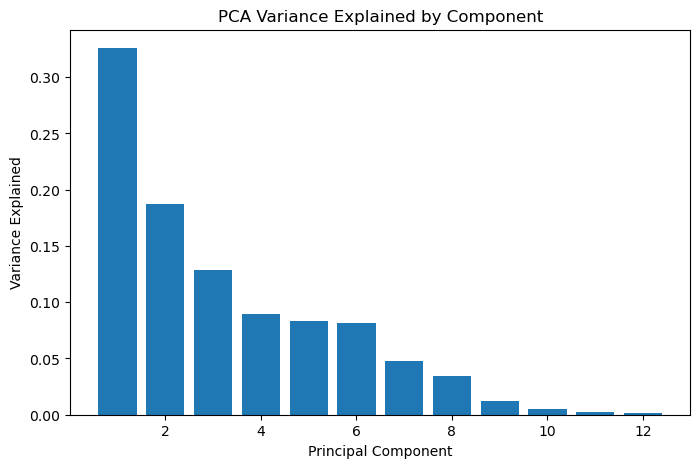

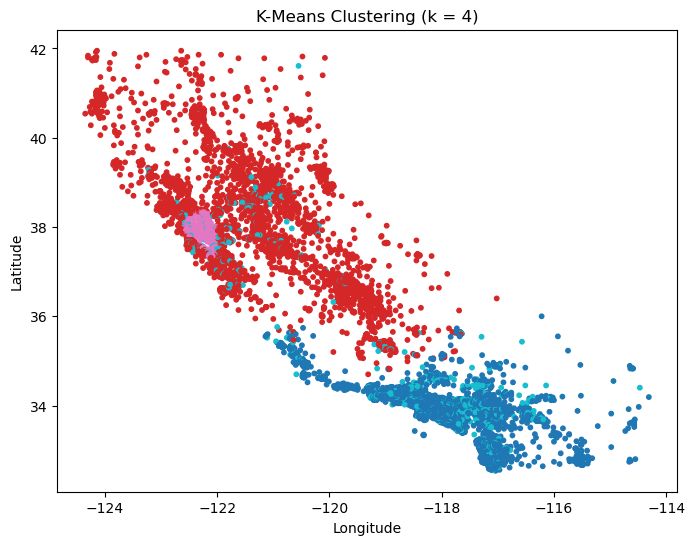

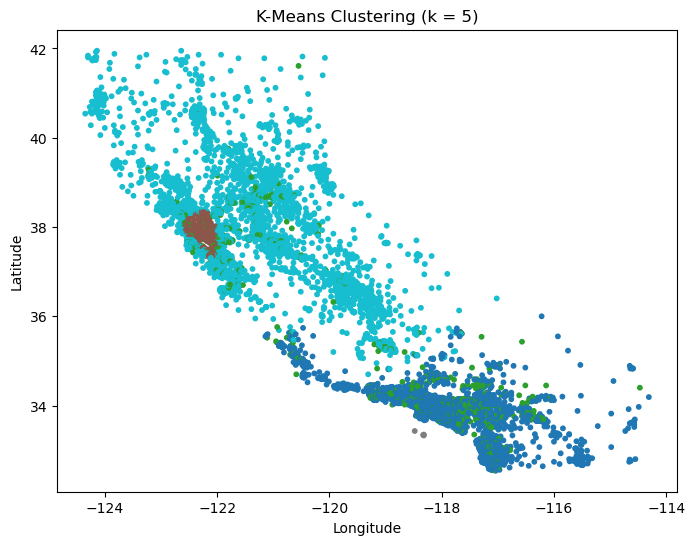

Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_234 (Dense)               │ (None, 10)             │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_235 (Dense)               │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_236 (Dense)               │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_237 (Dense)               │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_238 (Dense)               │ (None, 40)             │         1,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_239 (Dense)               │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,681 (10.47 KB)

 Trainable params: 2,681 (10.47 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 56421203968.0000 - mae: 207553.3906 - val_loss: 55092957184.0000 - val_mae: 204602.0625
Epoch 2/400
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 50134097920.0000 - mae: 192657.7344 - val_loss: 32563685376.0000 - val_mae: 147180.0469
Epoch 3/400
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16829895680.0000 - mae: 96292.8281 - val_loss: 10869208064.0000 - val_mae: 77167.8281
Epoch 4/400
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10159627264.0000 - mae: 74351.8516 - val_loss: 8732115968.0000 - val_mae: 69540.8281
Epoch 5/400
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8619639808.0000 - mae: 68187.1953 - val_loss: 7590943232.0000 - val_mae: 64536.7734
Epoch 6/400
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7727609344.0000 - mae: 64074.0234 - val_loss: 6867476992.0000 - val_mae: 60851.1797
Epoch 7/400
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7116513792.0000 - mae: 61010.1172 - val_loss: 6352013824.0

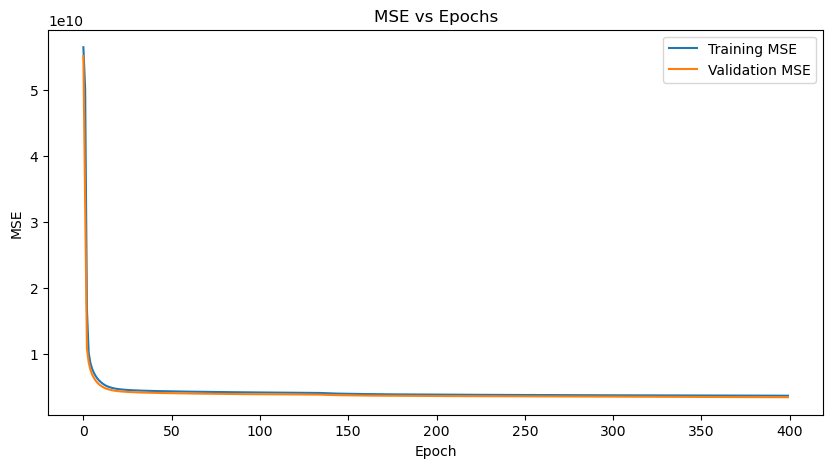

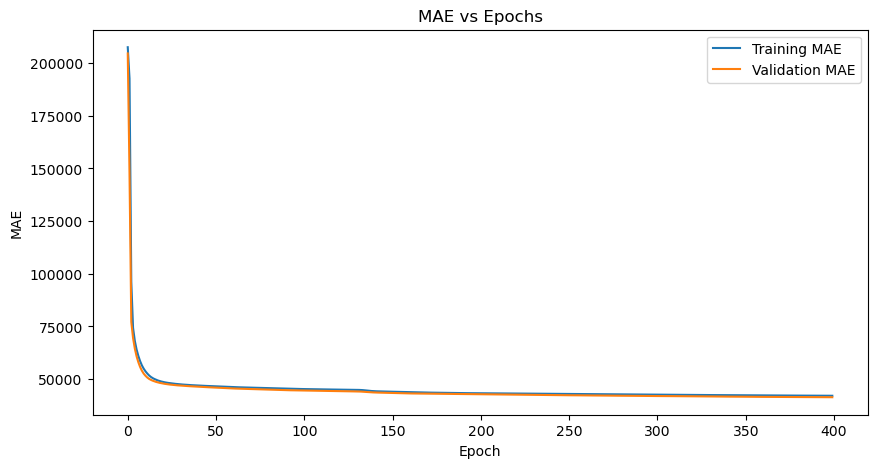

194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- MODEL PERFORMANCE ---
MSE: 3457438976.0000
MAE: 41424.3086
R2 : 0.7390


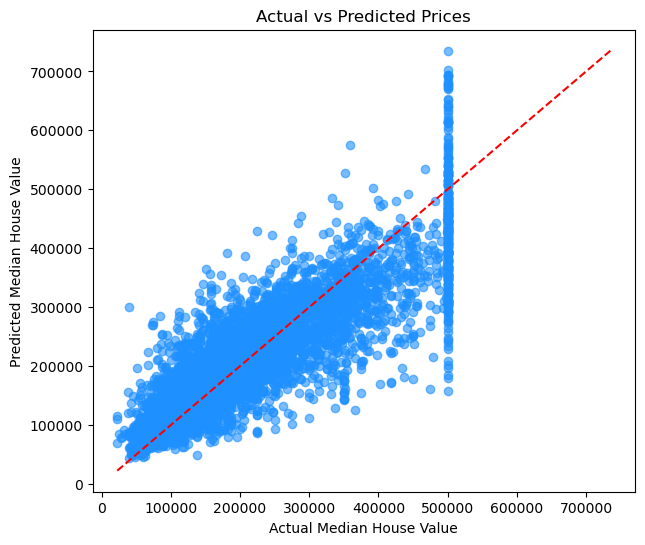


--- 10 SAMPLE PREDICTIONS ---
   Actual Price  Predicted Price
0        245300    244093.406250
1        104200    137637.250000
2        146200    182347.640625
3        154200    136714.828125
4        324200    218890.671875
5        141100    143464.921875
6        227300    235254.156250
7        202300    200554.468750
8        170200     91167.843750
9        301800    288792.500000


In [64]:
# ============================
# 1. IMPORTS
# ============================
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================
# 2. LOAD DATASET
# ============================
house = pd.read_csv("CustomisedCaliforniaHousingDataset.csv")

# ============================
# 3. DATA PREPROCESSING
# ============================

#Finding the null values in each column
null_columns = round(100*(house.isnull().sum()/len(house.index)),2)
print ( "Find Null columns" )
print ( null_columns )

#Filling null values from the column "total_bedrooms" to the mean of that column
house['total_bedrooms'].fillna((house['total_bedrooms'].mean()), inplace = True)

# Seperating the Categorical columns from the data
house_categorical = house.select_dtypes(include=['object'])

# Convert into dummies
house_dummies = pd.get_dummies(house_categorical, drop_first=True)

#Dropping the columns for which we have dummy values.
house = house.drop(list(house_categorical.columns), axis=1)
house= pd.concat([house, house_dummies], axis=1)
house1= house.drop(["median_house_value"], axis=1)
cols = house1.columns
house1 = pd.DataFrame(scale(house1))
house1.columns = cols

# ============================
# 4. ASSIGNING X and y
# ============================
# Assigning X and y where X are the independent variables and y is the dependent variable.
X = house1
y = house["median_house_value"].values

# ============================
# 4. VISUALIZATION — LOCATION VS VALUE
# ============================
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    house1["longitude"],
    house1["latitude"],
    c=house["median_house_value"],
    cmap="viridis",
    s=10
)
plt.colorbar(scatter, label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Median House Value Distribution by Location")
plt.show()


# ============================
# 5. PCA — VARIANCE ANALYSIS
# ============================
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA Variance Explained by Component")
plt.show()


# ============================
# 6. K-MEANS CLUSTERING (4 & 5)
# ============================

for k in [4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        house["longitude"],
        house["latitude"],
        c=clusters,
        cmap="tab10",
        s=10
    )
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"K-Means Clustering (k = {k})")
    plt.show()

# ============================
# 7. TRAIN / TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.7,
                                                    test_size = 0.3, random_state=100)


# ============================
# 8. BUILD DNN MODEL
# ============================
model = Sequential([
    Dense(10, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(20, activation="relu"),
    Dense(20, activation="relu"),
    Dense(30, activation="relu"),
    Dense(40, activation="relu"),
    Dense(1)
])

OPTIMIZER_TYPE = "ADAM" #change "ADAM" or "SGD"

if ( OPTIMIZER_TYPE == "ADAM" ):
    optimizer = Adam(learning_rate=0.001)
else:
    optimizer = SGD(learning_rate=0.001, momentum=0.9, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

model.summary()

# ============================
# 9. TRAIN WITH EARLY STOPPING
# ============================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=400,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)



# ============================
# 10. TRAINING CURVES
# ============================
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training MSE")
plt.plot(history.history["val_loss"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE vs Epochs")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("MAE vs Epochs")
plt.legend()
plt.show()


# ============================
# 11. EVALUATION METRICS
# ============================

y_pred = model.predict(X_test).flatten()


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE ---")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 : {r2:.4f}")


# ============================
# 12. ACTUAL VS PREDICTED
# ============================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, color="dodgerblue", alpha=0.6, label="Predictions")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Fit")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Prices")
plt.show()


# ============================
# 13. 10 EXAMPLE PREDICTIONS
# ============================
examples = pd.DataFrame({
    "Actual Price": y_test[:10],
    "Predicted Price": y_pred[:10]
})

print("\n--- 10 SAMPLE PREDICTIONS ---")
print(examples)

#Problem 1 - Part B Creating customized Dataset

In [65]:
import numpy as np
import pandas as pd

set_total_house = 500

bedrooms = np.random.randint(1, 4, set_total_house)#Randomly generate number of bedrooms between 1 and 4
bathrooms = np.random.randint(1, 4, set_total_house)#  Randomly generate number of bathrooms between 1 and 4
land_size = np.random.randint(100, 300, set_total_house)#Randomly generate land size between 100 and 300 square meters
distance_cbd = np.random.randint(10, 100, set_total_house)#Randomly generate distance from CBD between 10 and 100 kilometers
median_income = np.random.randint(50_000, 120_000, set_total_house)#Randomly generate median income between 50,000 and 120,000

# Price formula with noise to make it realistic
house_price = (
    (bedrooms * 100_000) + # 100k per bedroom
    (bathrooms * 50_000) + # 50k per bathroom
    (land_size * 2_000) +   # 2k per square meter
    (distance_cbd * 1_000) +  # 1k per KM in distance away from CBD
    median_income #The more the income the higher the price
)

df = pd.DataFrame({
    "total_bedrooms": bedrooms,
    "total_bathrooms": bathrooms,
    "land_size": land_size,
    "distance_from_cbd": distance_cbd,
    "median_income": median_income,
    "house_price": house_price
})

df.to_csv("MelbourneHousePrice.csv", index=False)

print("Dataset created: MelbourneHousePrice.csv")
print(df.head())


Dataset created: MelbourneHousePrice.csv
   total_bedrooms  total_bathrooms  land_size  distance_from_cbd  \
0               2                3        122                 69   
1               3                1        206                 12   
2               1                1        262                 76   
3               2                3        111                 81   
4               3                2        236                 64   

   median_income  house_price  
0         115324       778324  
1         115027       889027  
2          51425       801425  
3          51733       704733  
4          95375      1031375  


#Problem 1 - Part B - Applying the Neural Network Model

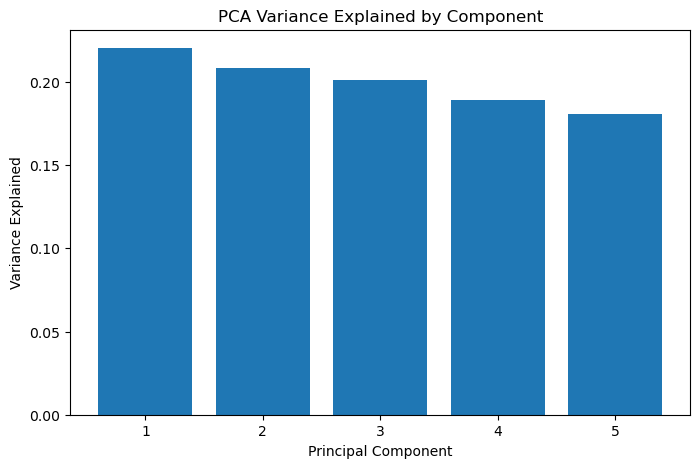

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_252 (Dense)               │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_253 (Dense)               │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_254 (Dense)               │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_255 (Dense)               │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 40)             │         1,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_257 (Dense)               │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611 (10.20 KB)

 Trainable params: 2,611 (10.20 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 732843474944.0000 - mae: 842741.1875 - val_loss: 702093852672.0000 - val_mae: 821567.3125
Epoch 2/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 732843147264.0000 - mae: 842741.0000 - val_loss: 702093524992.0000 - val_mae: 821567.0625
Epoch 3/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 732842950656.0000 - mae: 842740.9375 - val_loss: 702093131776.0000 - val_mae: 821566.8750
Epoch 4/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 732842426368.0000 - mae: 842740.6875 - val_loss: 702092673024.0000 - val_mae: 821566.6250
Epoch 5/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 732841836544.0000 - mae: 842740.3125 - val_loss: 702091952128.0000 - val_mae: 821566.1250
Epoch 6/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 732841050112.0000 - mae: 842739.7500 - val_loss: 702091034624.0000 - val_mae: 821565.6250
Epoch 7/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 732839936000.0000 - mae: 842739.1875 - val_loss: 70208

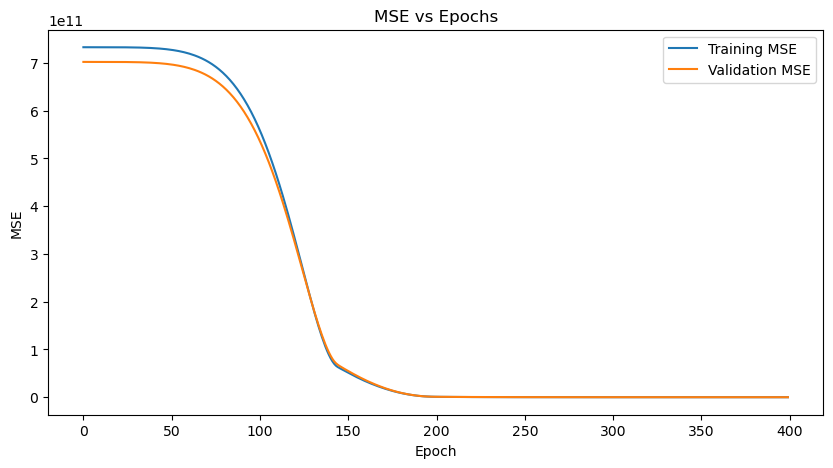

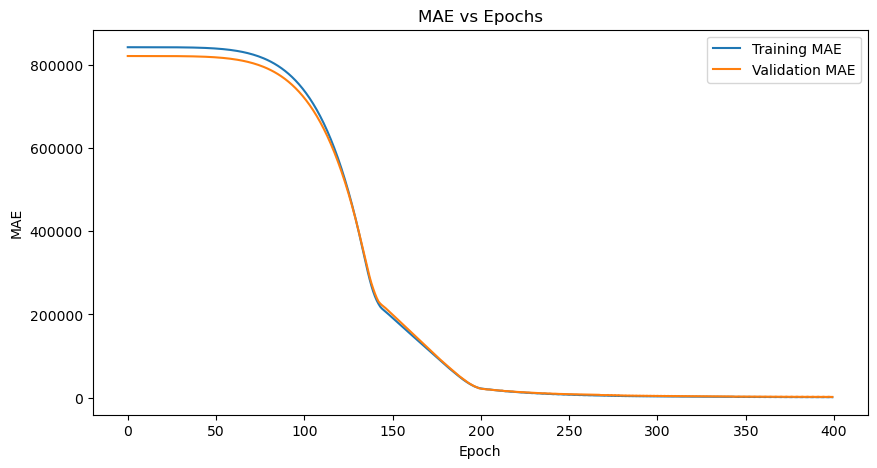

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

--- MODEL PERFORMANCE ---
MSE: 14641092.0000
MAE: 1743.0869
R2 : 0.9995


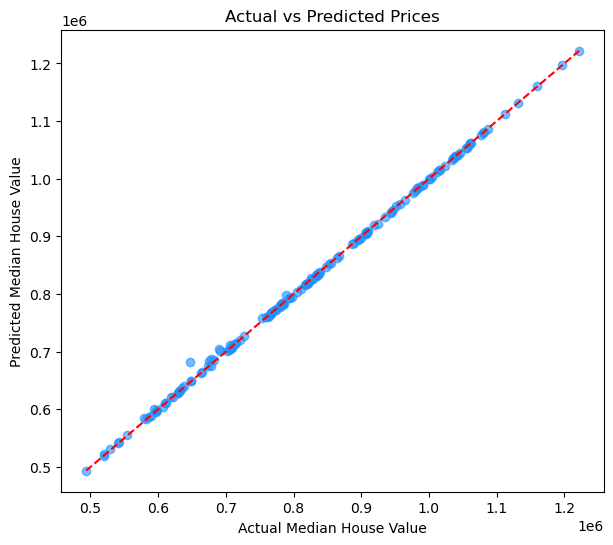


--- 10 SAMPLE PREDICTIONS ---
   Actual Price  Predicted Price
0       1004472          1002324
1        597583           597387
2        990574           989290
3       1043521          1041966
4        631233           631198
5        493613           493568
6       1023284          1022547
7        852887           852871
8        690621           704492
9        838930           837829


In [ ]:
# ============================
# 1. IMPORTS
# ============================
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================
# 2. LOAD DATASET
# ============================
house = pd.read_csv("MelbourneHousePrice.csv")

# ============================
# 3. DATA PREPROCESSING
# ============================
#Finding the null values in each column
house1= house.drop(["house_price"], axis=1)
house1 = pd.DataFrame(scale(house1))

# ============================
# 4. ASSIGNING X and y
# ============================
# Assigning X and y where X are the independent variables and y is the dependent variable.
X = house1
y = house["house_price"].values

# ============================
# 5. PCA — VARIANCE ANALYSIS
# ============================
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA Variance Explained by Component")
plt.show()


# # ============================
# # 6. K-MEANS CLUSTERING (4 & 5)
# # ============================

# for k in [4, 5]:
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     clusters = kmeans.fit_predict(X)

#     plt.figure(figsize=(8, 6))
#     plt.scatter(
#         house["longitude"],
#         house["latitude"],
#         c=clusters,
#         cmap="tab10",
#         s=10
#     )
#     plt.xlabel("Longitude")
#     plt.ylabel("Latitude")
#     plt.title(f"K-Means Clustering (k = {k})")
#     plt.show()

# ============================
# 7. TRAIN / TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.7,
                                                    test_size = 0.3, random_state=100)


# ============================
# 8. BUILD DNN MODEL
# ============================
model = Sequential([
    Dense(10, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(20, activation="relu"),
    Dense(20, activation="relu"),
    Dense(30, activation="relu"),
    Dense(40, activation="relu"),
    Dense(1)
])

OPTIMIZER_TYPE = "SGD" #change "ADAM" or "SGD"

if ( OPTIMIZER_TYPE == "ADAM" ):
    optimizer = Adam(learning_rate=0.001)
else:
    optimizer = SGD(learning_rate=0.001, momentum=0.9, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

model.summary()

# ============================
# 9. TRAIN WITH EARLY STOPPING
# ============================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=400,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)



# ============================
# 10. TRAINING CURVES
# ============================
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training MSE")
plt.plot(history.history["val_loss"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE vs Epochs")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("MAE vs Epochs")
plt.legend()
plt.show()


# ============================
# 11. EVALUATION METRICS
# ============================

y_pred = model.predict(X_test).flatten()


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE ---")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 : {r2:.4f}")


# ============================
# 12. ACTUAL VS PREDICTED
# ============================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, color="dodgerblue", alpha=0.6, label="Predictions")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Fit")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Prices")
plt.show()


# ============================
# 13. 10 EXAMPLE PREDICTIONS
# ============================
examples = pd.DataFrame({
    "Actual Price": y_test[:10],
    "Predicted Price": y_pred[:10]
})

# Format predicted values as normal numbers
examples["Predicted Price"] = examples["Predicted Price"].round(0).astype(int)

print("\n--- 10 SAMPLE PREDICTIONS ---")
print(examples)

#Problem 2 – Create Your Customised Dataset and Conduct Neural Network Experiments

Find Null columns
SampleID       0.0
Region         0.0
Area           0.0
palmitic       0.0
palmitoleic    0.0
stearic        0.0
oleic          0.0
linoleic       0.0
linolenic      0.0
arachidic      0.0
eicosenoic     0.0
Other          0.0
dtype: float64

Class distribution:
Extra Virgin: 480
Organic Extra Virgin: 92
Total: 572

After synthetic sampling:
Total samples: 622
Extra Virgin: 480
Organic Extra Virgin: 142


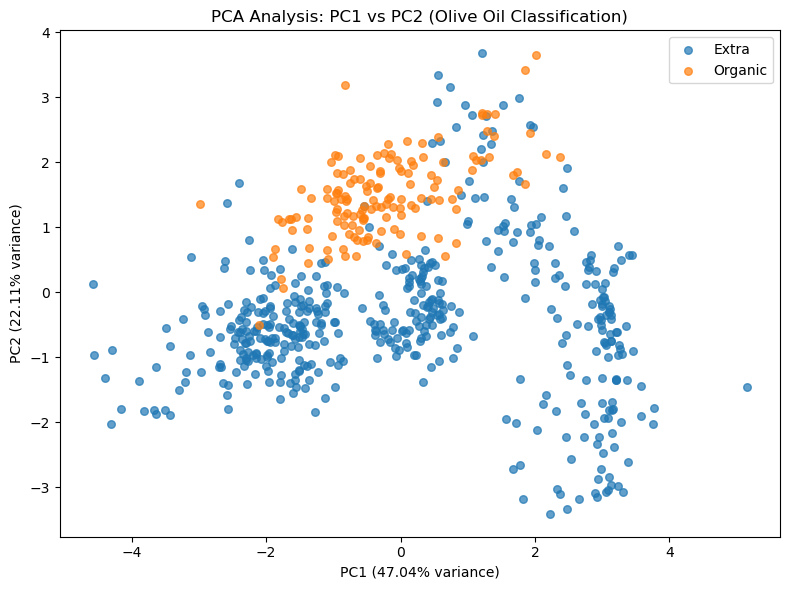

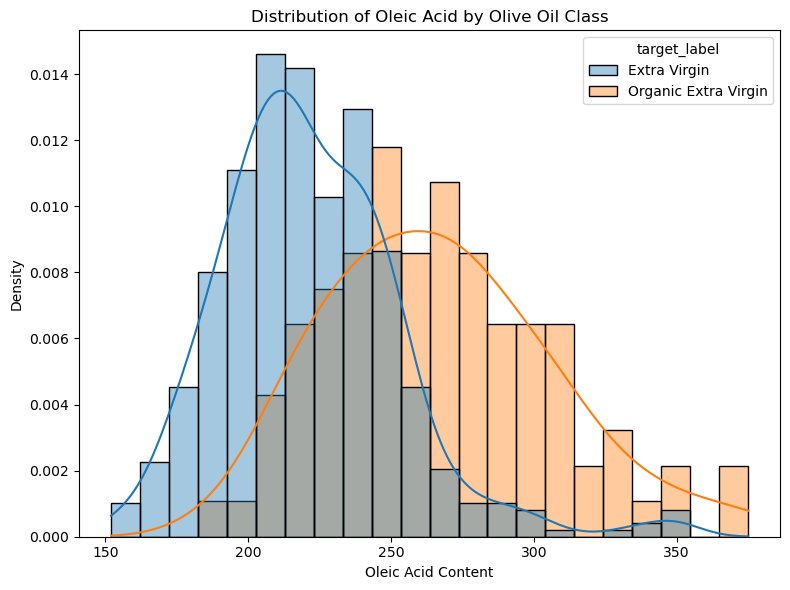


Train set: 497 samples
Test set: 125 samples

--- MODEL ARCHITECTURE ---


Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_258 (Dense)               │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_259 (Dense)               │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_260 (Dense)               │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_261 (Dense)               │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_262 (Dense)               │ (None, 40)             │         1,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_263 (Dense)               │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,641 (10.32 KB)

 Trainable params: 2,641 (10.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 0.7003 - loss: 0.6806 - val_accuracy: 0.7500 - val_loss: 0.6629
Epoch 2/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7783 - loss: 0.6537 - val_accuracy: 0.7500 - val_loss: 0.6391
Epoch 3/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7783 - loss: 0.6277 - val_accuracy: 0.7500 - val_loss: 0.6150
Epoch 4/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7783 - loss: 0.6008 - val_accuracy: 0.7500 - val_loss: 0.5887
Epoch 5/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7783 - loss: 0.5711 - val_accuracy: 0.7500 - val_loss: 0.5599
Epoch 6/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7783 - loss: 0.5383 - val_accuracy: 0.7500 - val_loss: 0.5289
Epoch 7/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7783 - loss: 0.5033 - val_accuracy: 0.7500 - val_loss: 0.4993
Epoch 8/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7783 - loss: 0.4696 - val_accuracy: 0.7500 - val_loss

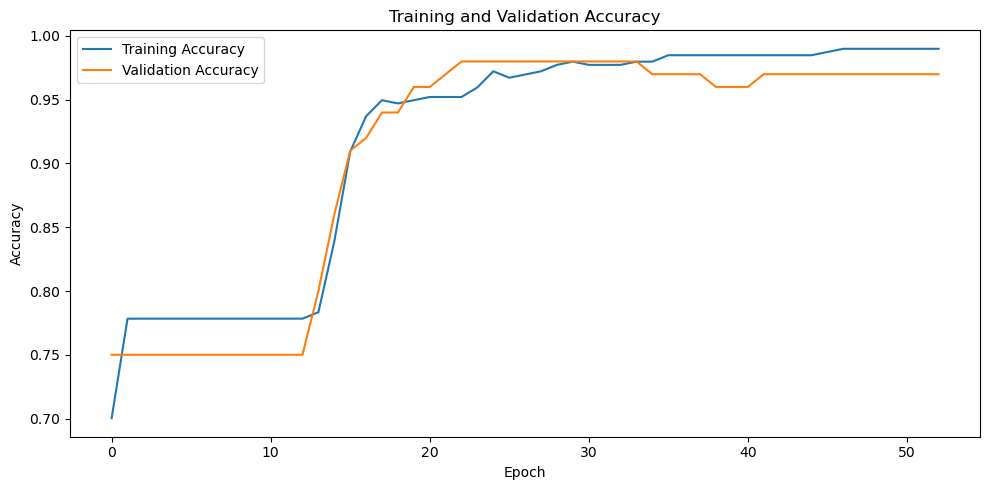


--- MODEL PERFORMANCE ---
Training Accuracy: 0.9799
Test Accuracy: 0.9920

--- TRAINING CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       Extra       0.99      0.98      0.99       384
     Organic       0.95      0.96      0.96       113

    accuracy                           0.98       497
   macro avg       0.97      0.97      0.97       497
weighted avg       0.98      0.98      0.98       497

--- TEST CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       Extra       0.99      1.00      0.99        96
     Organic       1.00      0.97      0.98        29

    accuracy                           0.99       125
   macro avg       0.99      0.98      0.99       125
weighted avg       0.99      0.99      0.99       125



In [69]:
# ============================
# 1. IMPORTS
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD

# ============================
# 2. LOAD DATASET
# ============================
olive = pd.read_csv("olive_original1.csv")


# ============================
# 3. DATA PREPROCESSING
# ============================

#Finding the null values in each column
null_columns = round(100*(olive.isnull().sum()/len(olive.index)),2)
print ( "Find Null columns" )
print ( null_columns )

# Create binary target: Organic if Area is Calabria or Sicily, else Extra ( Organic = 1 and Extra = 0)
olive['target'] = olive['Region'].astype(str).str.strip().apply(
    lambda x: 1 if x in ['Calabria', 'Sicily'] else 0
)

# Drop unecessary columns
olive = olive.drop(["SampleID", "Region", "Area", "Other"], axis=1)
olive_features = olive.drop(["target"], axis=1)

# ============================
# 4. ASSIGNING X and y
# ============================
# Assigning X and y where X are the independent variables and y is the dependent variable.
X = olive_features
y = olive["target"].values

print(f"\nClass distribution:")
print(f"Extra Virgin: {(y == 0).sum()}")
print(f"Organic Extra Virgin: {(y == 1).sum()}")
print(f"Total: {len(y)}")


# ============================
# 5. FEATURE SCALING
# ============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ============================
# 6. SYNTHETIC SAMPLING — GAUSSIAN MIXTURE MODEL
# ============================
# Generate 50 synthetic samples from minority class (Organic)
n_synthetic = 50
minority_X = X_scaled[y == 1]

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(minority_X)
synth_samples_scaled, _ = gmm.sample(n_synthetic)

# Inverse transform back to original feature scale
synth_samples = scaler.inverse_transform(synth_samples_scaled)
synth_labels = np.ones(n_synthetic, dtype=int)

# Append synthetic samples
X_aug = np.vstack([X, synth_samples])
y_aug = np.concatenate([y, synth_labels])
X_aug_scaled = np.vstack([X_scaled, synth_samples_scaled])

print(f"\nAfter synthetic sampling:")
print(f"Total samples: {len(y_aug)}")
print(f"Extra Virgin: {(y_aug == 0).sum()}")
print(f"Organic Extra Virgin: {(y_aug == 1).sum()}")

# ============================
# 7. VISUALIZATION — PCA ANALYSIS
# ============================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_aug_scaled)

plt.figure(figsize=(8, 6))
for cls in [0, 1]:
    idx = (y_aug == cls)
    label = 'Extra' if cls == 0 else 'Organic'
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=30, alpha=0.7, label=label)
plt.xlabel('PC1 ({:.2f}% variance)'.format(pca.explained_variance_ratio_[0] * 100))
plt.ylabel('PC2 ({:.2f}% variance)'.format(pca.explained_variance_ratio_[1] * 100))
plt.title('PCA Analysis: PC1 vs PC2 (Olive Oil Classification)')
plt.legend()
plt.tight_layout()
plt.show()


# ============================
# 8. VISUALIZATION — OLEIC DISTRIBUTION
# ============================

olive["target_label"] = olive["target"].map({
    0: "Extra Virgin",
    1: "Organic Extra Virgin"
})

plt.figure(figsize=(8, 6))
sns.histplot(
    data=olive, x='oleic', hue='target_label',
    kde=True, stat='density', common_norm=False,
    palette=['C0', 'C1'], alpha=0.4
)
plt.xlabel('Oleic Acid Content')
plt.ylabel('Density')
plt.title('Distribution of Oleic Acid by Olive Oil Class')
plt.tight_layout()
plt.show()


# ============================
# 9. TRAIN / TEST SPLIT  80-20
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)

# Scale train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {len(y_train)} samples")
print(f"Test set: {len(y_test)} samples")


# ============================
# 10. BUILD NEURAL NETWORK MODEL
# ============================
tf.random.set_seed(42)
model = Sequential([
    Dense(10, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(30, activation='relu'),
    Dense(40, activation='relu'),
    Dense(1, activation='sigmoid')
])

OPTIMIZER_TYPE = "ADAM" #change "ADAM" or "SGD"

if ( OPTIMIZER_TYPE == "ADAM" ):
    optimizer = Adam(learning_rate=0.001)
else:
    optimizer = SGD(learning_rate=0.001, momentum=0.9, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- MODEL ARCHITECTURE ---")
model.summary()


# ============================
# 11. TRAIN WITH EARLY STOPPING
# ============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=400,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# ============================
# 12. TRAINING CURVES
# ============================
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# ============================
# 13. EVALUATION METRICS
# ============================
# Get predictions (threshold at 0.5)
train_pred_prob = model.predict(X_train_scaled, verbose=0).ravel()
test_pred_prob = model.predict(X_test_scaled, verbose=0).ravel()

train_pred = (train_pred_prob >= 0.5).astype(int)
test_pred = (test_pred_prob >= 0.5).astype(int)

# Calculate accuracies
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\n--- MODEL PERFORMANCE ---")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Classification reports
report_train = classification_report(y_train, train_pred, target_names=['Extra', 'Organic'])
report_test = classification_report(y_test, test_pred, target_names=['Extra', 'Organic'])

print("\n--- TRAINING CLASSIFICATION REPORT ---")
print(report_train)

print("--- TEST CLASSIFICATION REPORT ---")
print(report_test)



